# PEDIC FEEMS dataset demo

This notebook demonstrates:
- Loading the PEDIC FEEMS-style files
- Building pseudo-sites and sampling a GeoTIFF
- Training the multi-species resistance model
- Visualizing learned edge resistances


In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys

import contextily as cx
import numpy as np
import torch

ROOT = os.path.dirname(os.path.dirname(os.getcwd())) if os.getcwd().endswith('notebooks') else os.getcwd()
sys.path.insert(0, os.path.join(ROOT, 'src'))

from multispecies_resistance.climate import download_climate_layers
from multispecies_resistance.io import list_pedic_species, load_pedic_species
from multispecies_resistance.train import build_species_graphs, train_model
from multispecies_resistance.viz import plot_multi_edge_resistance, plot_shared_resistance

torch.set_default_dtype(torch.float64)


In [2]:
PEDIC_DIR = '/Users/isaac/src/meems/pedic_feems_files'
species_names = list_pedic_species(PEDIC_DIR)
species_names[:5]


['anas', 'brevi', 'crano', 'densis', 'integ']

In [3]:
# Download and cache BioClim layers (used below by build_species_graphs)
raster_paths = download_climate_layers(
    source='bioclim',
    variables=['bio1', 'bio12'],
    resolution='2.5m',
    cache_dir='~/.cache/multispecies_resistance/climate',
)
len(raster_paths), raster_paths[:2]


(19,
 [PosixPath('/Users/isaac/.cache/multispecies_resistance/climate/bioclim/wc2.1/2.5m/bio/wc2.1_2.5m_bio_1.tif'),
  PosixPath('/Users/isaac/.cache/multispecies_resistance/climate/bioclim/wc2.1/2.5m/bio/wc2.1_2.5m_bio_2.tif')])

In [4]:
# Load a subset of species (sample-level only)
species_list = load_pedic_species(
    PEDIC_DIR,
    species_names=species_names,
    mmap_mode='r',
)
[s.name for s in species_list]


['anas',
 'brevi',
 'crano',
 'densis',
 'integ',
 'kansu',
 'lachno',
 'longi',
 'rhinanth',
 'szet',
 'tenu',
 'vert']

In [35]:
# Build graphs and train
graphs, stats = build_species_graphs(
    species_list,
    project_to='EPSG:3857',
    mesh_grid_type='triangular',
    bbox='convex_hull',
    #bbox_file="../../pedic_grid/hengduan_outer_latlong.txt",
    mesh_spacing_km=50,
    buffer_km=50.0,
    coord_order='latlon',
    coords_crs='EPSG:4326',
    raster_paths=raster_paths,
    raster_fill_method='nearest',
    standardize=True,
    use_geodesic=True,
    support_decay_km=150,
)


In [36]:
model = train_model(graphs, hidden_dim=32, lr=1e-2, epochs=500, log_every=25, edge_smoothing=0.75)

epoch   25 loss 0.438917 val 0.039371
epoch   50 loss 0.292241 val 0.027942
epoch   75 loss 0.228516 val 0.022388
epoch  100 loss 0.201448 val 0.019910
epoch  125 loss 0.189539 val 0.018702
epoch  150 loss 0.184073 val 0.018077
epoch  175 loss 0.181470 val 0.017732
epoch  200 loss 0.180085 val 0.017546
epoch  225 loss 0.179430 val 0.017430
epoch  250 loss 0.178788 val 0.017350
early stop at epoch 262 val 0.017321 best 0.017403


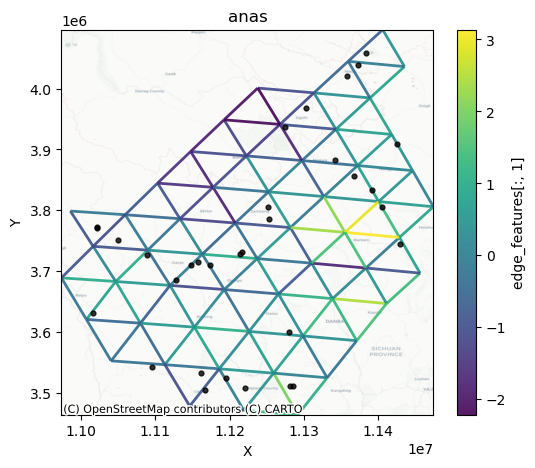

In [32]:
# Visualize edge-feature map for the selected species graph
spidx = 0
ax, gdf = graphs[spidx].plot(
    edge_feature_idx=1,
    basemap=True,
    title=species_list[spidx].name,
)


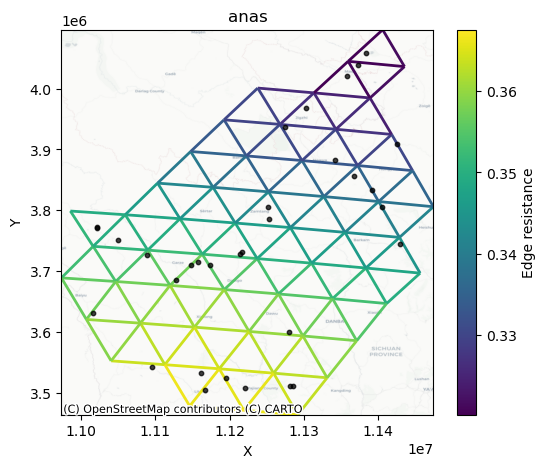

In [33]:
# Multi-species edge resistances (subplot grid)
_ = plot_multi_edge_resistance(
    species_list,
    graphs,
    model,
    basemap=True,
    show_sites=True,
    explore=True,
    cmap="viridis",
)


In [22]:
import matplotlib.pyplot as plt
#fig = plt.gcf()

#fig.savefig("/Users/isaac/Downloads/tmp/meadow_multi.png")


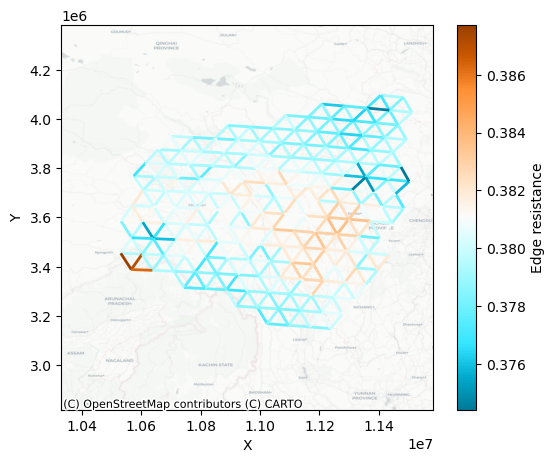

In [27]:
# Shared resistance surface (rasterized)
fig = plot_shared_resistance(
    species_list,
    graphs,
    model,
    #graph_index=1,
    rasterize=False,
    interpolation='kriging',
    grid_size=200,
    explore=True,
    show_sites=False,
)
fig[2]

In [ ]:

# Optional: interactive explore map (all species overlay)
ax, gdf, fmap = plot_multi_edge_resistance(
    species_list,
    graphs,
    model,
    overlay=True,
    explore=True,
    #cmap=None,
)
fmap


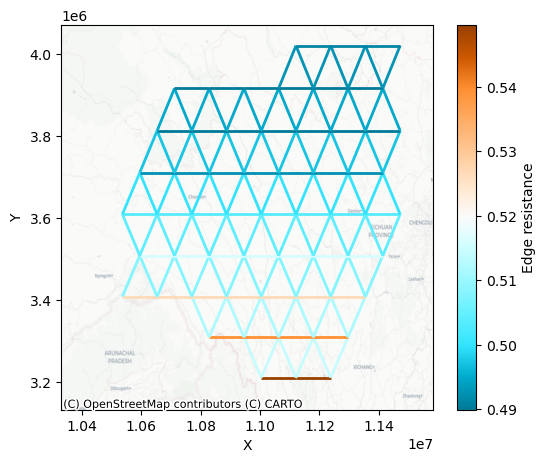

In [50]:
# Shared resistance surface (rasterized)
fig = plot_shared_resistance(
    species_list,
    graphs,
    model,
    #graph_index=1,
    rasterize=False,
    #interpolation='kriging',
    grid_size=200,
    #explore=True,
    #show_sites=True,
)


In [21]:
from multispecies_resistance.cv import choose_edge_smoothing_cv

res = choose_edge_smoothing_cv(graphs)



choose_edge_smoothing_cv: best edge_smoothing=0.1000 (mean_validation_loss=0.015747)                                    
edge_smoothing CV summary:
  edge_smoothing=0.0000 mean_validation_loss=0.022024 std=0.008491
  edge_smoothing=0.0500 mean_validation_loss=0.019968 std=0.005404
  edge_smoothing=0.1000 mean_validation_loss=0.015747 std=0.003000
  edge_smoothing=0.2000 mean_validation_loss=0.016090 std=0.002342
  edge_smoothing=0.3500 mean_validation_loss=0.016764 std=0.002273
  edge_smoothing=0.5000 mean_validation_loss=0.018352 std=0.003126
  edge_smoothing=0.7000 mean_validation_loss=0.019968 std=0.004135
  edge_smoothing=0.8500 mean_validation_loss=0.024410 std=0.003181
  edge_smoothing=0.9300 mean_validation_loss=0.025802 std=0.002670
  edge_smoothing=0.9700 mean_validation_loss=0.024791 std=0.002923


In [7]:
ax, gdf = graphs[spidx].plot(edge_feature_idx=1, basemap=True)

array([0.64941706, 0.66244312, 0.45468496, 0.66243263, 0.66244312,
       0.66243261, 0.45573106, 0.43956421, 0.45573106, 0.30225023,
       0.45375632, 0.29299039, 0.29299039, 0.29299039, 1.        ,
       0.66244312, 0.69334511, 0.69324956, 0.66243261, 0.65960505,
       0.15485875, 0.10873122, 0.15485875, 0.15267141, 0.15485875,
       0.15485875, 0.66239065, 0.64942687, 1.        , 0.66227525,
       0.65892206, 0.65960078, 0.32881888, 0.23007796, 0.32881888,
       0.32476324, 0.32881888, 0.22725353, 0.32888022, 0.32888022,
       0.32888022, 0.32556991, 0.65892206, 0.64925558, 0.65892206,
       0.65892206, 0.43755115, 0.65892206, 0.43624921, 0.28612381,
       0.43624921, 0.29065263, 0.43067678, 0.28940504, 0.65909153,
       1.        , 0.65960078, 1.        , 0.64941706, 0.43940216,
       0.46075453, 0.45406363, 0.66156351, 0.66156351, 0.6933538 ,
       0.6933538 , 0.6933538 , 0.6933538 , 0.6933538 , 0.6933538 ,
       0.68633984, 0.66244312, 0.69321483, 0.66240625, 0.45827